In [8]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import os
import numpy as np
import matplotlib.pyplot as plt
from torch.amp import GradScaler, autocast

from model import SASRecModel, negative_sampling_loss

In [9]:
# метрики
def ndcg_at_k(rel, pred, k=10):
    ndcg = 0.0
    if rel in pred[:k]:
        pred_list = list(pred[:k])
        score = pred_list.index(rel) + 1
        ndcg = 1.0 / np.log2(score + 1)
        return ndcg
    return ndcg

def recall_at_k(rel, pred, k=10):
    recall = 1.0 if rel in pred[:k] else 0.0
    return recall

In [13]:
# загрузка данных
data = torch.load('preprocessed_data.pt')
train_inputs = data['train_inputs']
train_targets = data['train_targets']
train_authors = data['train_authors']
train_categories = data['train_categories']
validate_inputs = data['validate_inputs']
validate_targets = data['validate_targets']
validate_authors = data['validate_authors']
validate_categories = data['validate_categories']
cnt_item = data['cnt_item']
cnt_author = data['cnt_author']
cnt_category = data['cnt_category']

print(f"Train: {len(train_inputs)} примеров")
print(f"Validate: {len(validate_inputs)} примеров")

C:\Users\1\AppData\Local\Temp\ipykernel_22632\1419990751.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load('preprocessed_data.pt')


Train: 554526 примеров
Validate: 120934 примеров


In [14]:
batch_size = 32
train_dataset = TensorDataset(train_inputs, train_targets,
                               train_authors, train_categories)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [15]:
# создание модели
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = SASRecModel(cnt_item=cnt_item, max_seq_len=30,
                     hidden_dim=128, num_heads=2, num_layers=2, dropout=0.2,
                     cnt_authors=cnt_author, cnt_categories=cnt_category).to(device)
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda
Параметров: 45,508,063


In [16]:
# проверка метрик на валидации
def check_metrics_validate(model, validate_inputs, validate_targets,
                           validate_authors, validate_categories,
                           k=10, batch_size=16):
    model.eval()
    ndcg_scores, recall_scores = [], []

    with torch.no_grad():
        for i in tqdm(range(0, len(validate_inputs), batch_size), desc="Validate"):
            batch_input = validate_inputs[i:i+batch_size].to(device)
            batch_target = validate_targets[i:i+batch_size]
            batch_authors = validate_authors[i:i+batch_size].to(device)
            batch_categories = validate_categories[i:i+batch_size].to(device)

            logits = model(batch_input, batch_authors, batch_categories)
            scores = logits[:, -1, :]
            _, pred = torch.topk(scores, k=k, dim=1)
            pred = pred.cpu().numpy()

            for j in range(len(batch_target)):
                target = batch_target[j].item()
                ndcg_scores.append(ndcg_at_k(target, pred[j], k))
                recall_scores.append(recall_at_k(target, pred[j], k))

    model.train()
    return np.mean(ndcg_scores), np.mean(recall_scores)

In [17]:
# обучение
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scaler = GradScaler('cuda')
os.makedirs('checkpoints', exist_ok=True)

best_ndcg = 0.0
check_validate = 2
patience = 3
patience_counter = 0

history = {
    'epoch': [],
    'train_loss': [],
    'validate_ndcg': [],
    'validate_recall': []
}

for epoch in range(1, 25):
    model.train()
    total_loss = 0

    for inputs, targets, authors, categories in tqdm(train_loader, desc=f"Epoch {epoch}/25"):
        inputs, targets = inputs.to(device), targets.to(device)
        authors, categories = authors.to(device), categories.to(device)

        with autocast('cuda'):
            logits = model(inputs, authors, categories)
            loss = negative_sampling_loss(logits[:, -1, :], targets, cnt_item, num_negatives=300)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    history['epoch'].append(epoch)
    history['train_loss'].append(avg_loss)

    if epoch % check_validate == 0:
        validate_ndcg, validate_recall = check_metrics_validate(
            model, validate_inputs, validate_targets,
            validate_authors, validate_categories, k=10, batch_size=16
        )
        history['validate_ndcg'].append(validate_ndcg)
        history['validate_recall'].append(validate_recall)

        print(f'Epoch {epoch:2d} | Train Loss: {avg_loss:.4f} | Validate NDCG@10: {validate_ndcg:.4f} | Validate Recall@10: {validate_recall:.4f}')

        if validate_ndcg > best_ndcg:
            best_ndcg = validate_ndcg
            patience_counter = 0
            torch.save(model.state_dict(), 'checkpoints/sasrec_improved_best.pth')
            print(f'Лучшая модель сохранена (NDCG@10: {best_ndcg:.4f})')
        else:
            patience_counter += 1
            print(f'Нет улучшения ({patience_counter}/{patience})')

        if patience_counter >= patience:
            print(f'Ранняя остановка на эпохе {epoch}')
            break
    else:
        history['validate_ndcg'].append(None)
        history['validate_recall'].append(None)
        print(f'Epoch {epoch:2d} | Train Loss: {avg_loss:.4f}')

print(f'Лучшая метрика NDCG@10 на валидации: {best_ndcg:.4f}')

Epoch 1/25: 100%|██████████| 17329/17329 [08:11<00:00, 35.25it/s]


Epoch  1 | Train Loss: 4.2939


Validate: 100%|██████████| 7559/7559 [00:32<00:00, 235.08it/s]


Epoch  2 | Train Loss: 3.3209 | Validate NDCG@10: 0.2527 | Validate Recall@10: 0.4500
Лучшая модель сохранена (NDCG@10: 0.2527)


Epoch 3/25: 100%|██████████| 17329/17329 [08:13<00:00, 35.13it/s]


...

Epoch  6 | Train Loss: 3.2149 | Validate NDCG@10: 0.2206 | Validate Recall@10: 0.4097
Нет улучшения (2/3)


Epoch 7/25: 100%|██████████| 17329/17329 [08:13<00:00, 35.11it/s]


Epoch  7 | Train Loss: 2.6063


Validate: 100%|██████████| 7559/7559 [00:31<00:00, 236.75it/s]

Epoch  8 | Train Loss: 2.9732 | Validate NDCG@10: 0.2437 | Validate Recall@10: 0.4443
Нет улучшения (3/3)
Ранняя остановка на эпохе 8
Лучшая метрика NDCG@10 на валидации: 0.2527


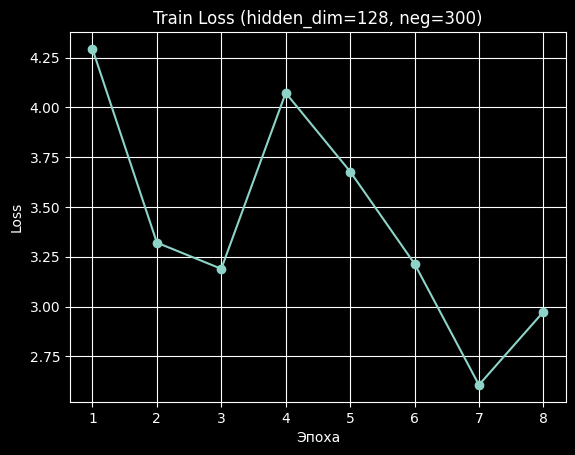

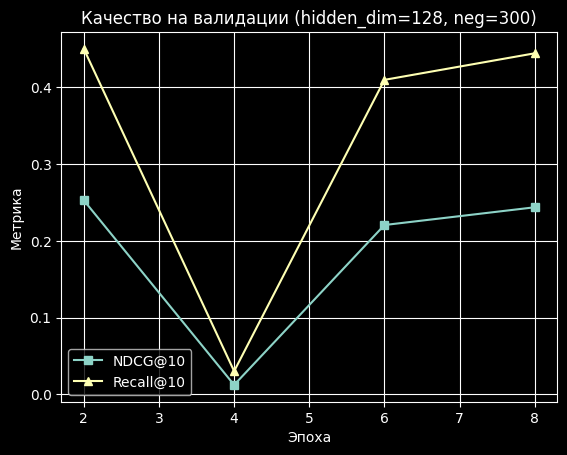

In [18]:
# графики метрики и потери
plt.figure()
plt.plot(history['epoch'], history['train_loss'], marker='o')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Train Loss (hidden_dim=128, neg=300)')
plt.grid(True)
plt.show()

val_epochs = [e for e, v in zip(history['epoch'], history['validate_ndcg']) if v is not None]
val_ndcg_clean = [v for v in history['validate_ndcg'] if v is not None]
val_recall_clean = [v for v in history['validate_recall'] if v is not None]

plt.figure()
plt.plot(val_epochs, val_ndcg_clean, marker='s', label='NDCG@10')
plt.plot(val_epochs, val_recall_clean, marker='^', label='Recall@10')
plt.xlabel('Эпоха')
plt.ylabel('Метрика')
plt.title('Качество на валидации (hidden_dim=128, neg=300)')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# оценка на тесте
test_inputs = data['test_inputs']
test_targets = data['test_targets']
test_authors = data['test_authors']
test_categories = data['test_categories']
k_values = [10, 50, 100]

model.load_state_dict(torch.load('checkpoints/sasrec_improved_best.pth', map_location=device))
model.eval()

ndcg_scores = {k: [] for k in k_values}
recall_scores = {k: [] for k in k_values}

with torch.no_grad():
    for i in tqdm(range(len(test_inputs)), desc="Тест"):
        inp = test_inputs[i].unsqueeze(0).to(device)
        auth = test_authors[i].unsqueeze(0).to(device)
        cat = test_categories[i].unsqueeze(0).to(device)
        target = test_targets[i].item()
        scores = model(inp, auth, cat)[0, -1, :]
        _, pred = torch.topk(scores, k=max(k_values), dim=0)
        pred = pred.cpu().numpy()
        for k in k_values:
            ndcg_scores[k].append(ndcg_at_k(target, pred, k))
            recall_scores[k].append(recall_at_k(target, pred, k))

for k in k_values:
    print(f"NDCG@{k:<3}   {np.mean(ndcg_scores[k]):.4f}")
    print(f"Recall@{k:<3} {np.mean(recall_scores[k]):.4f}")
    print()

C:\Users\1\AppData\Local\Temp\ipykernel_22632\556652146.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('checkpoints/sasrec_improved_bes

NDCG@10    0.2562
Recall@10  0.4569

NDCG@50    0.2772
Recall@50  0.5443

NDCG@100   0.2802
Recall@100 0.5625

